In [12]:
import zstandard as zstd
import json
import io
from collections import defaultdict
import matplotlib.pyplot as plt

file_path = "../../../Downloads/reddit/comments/RC_2015-06.zst"

target_subs = {"fatpeoplehate", "politics", "worldnews"}

# 🔴 Define explicit time window (1 week)
START = 1433116800  # June 1, 2015
END = START + 30 * 24 * 3600  # 30 days

data_list = []

with open(file_path, "rb") as f:
    dctx = zstd.ZstdDecompressor(max_window_size=2**31)
    stream = dctx.stream_reader(f)
    text_stream = io.TextIOWrapper(stream, encoding="utf-8")

    for line in text_stream:
        data = json.loads(line)

        # ✅ Filter by subreddit
        if data.get("subreddit") not in target_subs:
            continue

        # ✅ Filter by time window
        t = int(data["created_utc"])
        if t < START or t > END:
            continue

        data_list.append({
            "author": data["author"],
            "parent_id": data["parent_id"],
            "score": data["score"],
            "time": t,
            "subreddit": data["subreddit"]
        })

print("Collected:", len(data_list))

# ----------------------------
# 🔴 TIME SERIES
# ----------------------------

time_series = defaultdict(list)

for d in data_list:
    day = d["time"] // (24 * 3600)
    time_series[day].append(d)

x_t = {}  # normalized activity
T_t = {}  # trust

# 🔥 Normalize x(t)
max_activity = max(len(v) for v in time_series.values())

for day, items in sorted(time_series.items()):
    x_t[day] = len(items) / max_activity  # normalized [0,1]
    T_t[day] = sum(d["score"] for d in items) / len(items)

print("\nTime Series:")
for day in sorted(x_t.keys()):
    print(f"Day {day}: x={x_t[day]:.3f}, T={T_t[day]:.3f}")

# ----------------------------
# 🔴 NETWORK (still partial)
# ----------------------------

edges = []

for d in data_list:
    if d["parent_id"].startswith("t1_"):
        edges.append((d["author"], d["parent_id"]))

print("\nEdges:", len(edges))

Collected: 812221

Time Series:
Day 16587: x=0.748, T=6.374
Day 16588: x=0.671, T=8.503
Day 16589: x=0.592, T=5.477
Day 16590: x=0.608, T=6.581
Day 16591: x=0.489, T=6.209
Day 16592: x=0.392, T=5.473
Day 16593: x=0.532, T=7.550
Day 16594: x=0.685, T=7.787
Day 16595: x=0.587, T=6.480
Day 16596: x=0.579, T=6.266
Day 16597: x=0.578, T=6.787
Day 16598: x=0.574, T=6.552
Day 16599: x=0.389, T=6.502
Day 16600: x=0.447, T=6.101
Day 16601: x=0.532, T=7.703
Day 16602: x=0.685, T=5.885
Day 16603: x=0.683, T=5.806
Day 16604: x=0.692, T=6.897
Day 16605: x=0.636, T=7.524
Day 16606: x=0.593, T=7.512
Day 16607: x=0.436, T=6.626
Day 16608: x=0.612, T=5.400
Day 16609: x=0.592, T=5.890
Day 16610: x=0.714, T=6.952
Day 16611: x=0.733, T=7.315
Day 16612: x=1.000, T=7.822
Day 16613: x=0.545, T=7.574
Day 16614: x=0.597, T=8.816
Day 16615: x=0.576, T=6.759
Day 16616: x=0.717, T=7.093

Edges: 655757


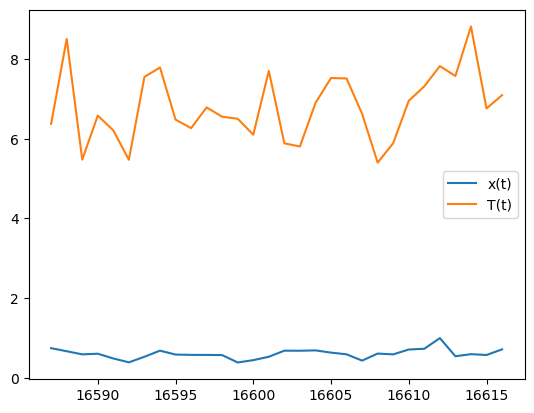

In [13]:
import matplotlib.pyplot as plt

days = sorted(x_t.keys())

x_vals = [x_t[d] for d in days]
T_vals = [T_t[d] for d in days]

plt.plot(days, x_vals, label="x(t)")
plt.plot(days, T_vals, label="T(t)")
plt.legend()
plt.show()

In [14]:
lag_corr = []

for i in range(len(days)-1):
    lag_corr.append((T_vals[i], x_vals[i+1]))

print(lag_corr[:5])

[(6.373604944197768, 0.6709726614187356), (8.503375894110569, 0.5921415595774743), (5.476536757186683, 0.6082666128417322), (6.581446795959, 0.4890443831438247), (6.20852059066312, 0.392002511830272)]


In [15]:
x_t = {}

for day, items in sorted(time_series.items()):
    low_score = sum(1 for d in items if d["score"] <= 0)
    x_t[day] = low_score / len(items)

In [16]:
x_vals = [x_t[d] for d in days]
T_vals = [T_t[d] for d in days]

lag_corr = [(T_vals[i], x_vals[i+1]) for i in range(len(days)-1)]
print(lag_corr)

[(6.373604944197768, 0.185774450163781), (8.503375894110569, 0.20444646441692232), (5.476536757186683, 0.21606076248064301), (6.581446795959, 0.21567458497661193), (6.20852059066312, 0.21797585674237657), (5.473310830139024, 0.22970522498207735), (7.550457554927677, 0.23274987731064944), (7.78688041877965, 0.2212926885170754), (6.480021392008557, 0.22258776173704378), (6.266362193753145, 0.1902287708414114), (6.7866614967041485, 0.22430308480275246), (6.55201939242288, 0.22664589463966303), (6.501586752062778, 0.2399478592198937), (6.100822219993984, 0.21898179366149698), (7.703430546190155, 0.23668793978072328), (5.8847979054164625, 0.23342418968178386), (5.805753505631999, 0.21051607883817428), (6.896816649377594, 0.21536834684525907), (7.523757490306662, 0.23640831758034025), (7.511758034026465, 0.24020793658963405), (6.626228833187503, 0.22948957531787037), (5.40027848008501, 0.21713592784872485), (5.890333093334344, 0.22692005654154232), (6.951971100989477, 0.18659730722154222), (

In [17]:
g_t = {}

for day, items in sorted(time_series.items()):
    enforced = sum(1 for d in items if d["score"] <= -2)
    g_t[day] = enforced / len(items)

In [18]:
print([(g_t[d], x_t[next_day]) for d, next_day in zip(days, days[1:])])

[(0.07677307092283692, 0.185774450163781), (0.062069657062637874, 0.20444646441692232), (0.0723781388478582, 0.21606076248064301), (0.07621119386475923, 0.21567458497661193), (0.08066587177840961, 0.21797585674237657), (0.07981005778362607, 0.22970522498207735), (0.08400455446379623, 0.23274987731064944), (0.08192376901684933, 0.2212926885170754), (0.0831232332492933, 0.22258776173704378), (0.07620853814297325, 0.1902287708414114), (0.062388522683210546, 0.22430308480275246), (0.07197873089103492, 0.22664589463966303), (0.07847210201373261, 0.2399478592198937), (0.09931815902937932, 0.21898179366149698), (0.0833614295347269, 0.23668793978072328), (0.08695794468990345, 0.23342418968178386), (0.08590850875176513, 0.21051607883817428), (0.07387837136929461, 0.21536834684525907), (0.07349312654212196, 0.23640831758034025), (0.09228733459357277, 0.24020793658963405), (0.09269648463636831, 0.22948957531787037), (0.07720493935729728, 0.21713592784872485), (0.07901019364128993, 0.2269200565415

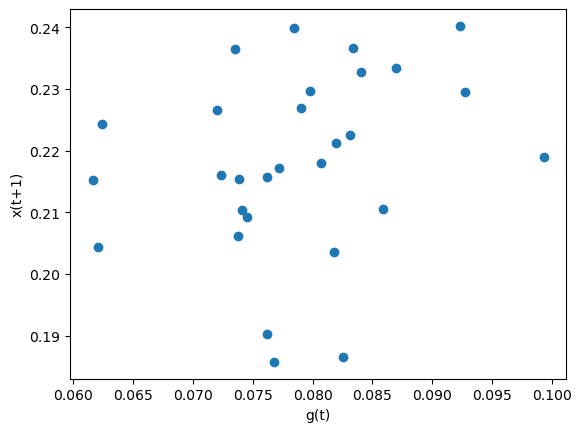

In [19]:
import matplotlib.pyplot as plt

g_vals = [g_t[d] for d in days[:-1]]
x_next = [x_t[d] for d in days[1:]]

plt.scatter(g_vals, x_next)
plt.xlabel("g(t)")
plt.ylabel("x(t+1)")
plt.show()

In [20]:
import numpy as np

coef = np.polyfit(g_vals, x_next, 1)
print("Slope:", coef[0])

Slope: 0.4347278769436133


In [21]:
import numpy as np

x_vals = [x_t[d] for d in days[:-1]]
x_next = [x_t[d] for d in days[1:]]
g_vals = [g_t[d] for d in days[:-1]]

X = np.column_stack([g_vals, x_vals])
Y = np.array(x_next)

coef = np.linalg.lstsq(X, Y, rcond=None)[0]

print("Effect of g:", coef[0])
print("Effect of x:", coef[1])

Effect of g: -0.9815685075677061
Effect of x: 1.34816662937076


In [22]:
import numpy as np

x_vals = [x_t[d] for d in days[:-1]]
x_next = [x_t[d] for d in days[1:]]
g_vals = [g_t[d] for d in days[:-1]]
T_vals = [T_t[d] for d in days[:-1]]

interaction = [g_vals[i]*T_vals[i] for i in range(len(g_vals))]

X = np.column_stack([g_vals, x_vals, interaction])
Y = np.array(x_next)

coef = np.linalg.lstsq(X, Y, rcond=None)[0]

print("g:", coef[0])
print("x:", coef[1])
print("g*T:", coef[2])

g: -1.2016094882000852
x: 1.3137042277195432
g*T: 0.04673365381658612


In [24]:
import numpy as np

# Prepare aligned lists
days_sorted = sorted(x_t.keys())

x_vals = [x_t[d] for d in days_sorted[:-1]]
x_next = [x_t[d] for d in days_sorted[1:]]
g_vals = [g_t[d] for d in days_sorted[:-1]]
T_vals = [T_t[d] for d in days_sorted[:-1]]

# 🔴 Split threshold (you can tweak this later)
T_threshold = 6.5

low_g, low_xnext = [], []
high_g, high_xnext = [], []

for i in range(len(g_vals)):
    if T_vals[i] < T_threshold:
        low_g.append(g_vals[i])
        low_xnext.append(x_next[i])
    else:
        high_g.append(g_vals[i])
        high_xnext.append(x_next[i])

# 🔴 Function to compute slope
def compute_slope(g, x):
    if len(g) < 2:
        return None
    coef = np.polyfit(g, x, 1)
    return coef[0]

# Compute slopes
low_slope = compute_slope(low_g, low_xnext)
high_slope = compute_slope(high_g, high_xnext)

print("Slope (low T):", low_slope)
print("Slope (high T):", high_slope)

Slope (low T): 0.6724312542535927
Slope (high T): 0.4962675263467362


In [25]:
def regression(g, x, x_next):
    import numpy as np
    X = np.column_stack([g, x])
    Y = np.array(x_next)
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    return coef

low_idx = [i for i in range(len(T_vals)) if T_vals[i] < 6.5]
high_idx = [i for i in range(len(T_vals)) if T_vals[i] >= 6.5]

low_coef = regression(
    [g_vals[i] for i in low_idx],
    [x_vals[i] for i in low_idx],
    [x_next[i] for i in low_idx]
)

high_coef = regression(
    [g_vals[i] for i in high_idx],
    [x_vals[i] for i in high_idx],
    [x_next[i] for i in high_idx]
)

print("Low T:", low_coef)
print("High T:", high_coef)

Low T: [0.28477363 0.85881329]
High T: [-1.40001762  1.51456283]


In [26]:
import numpy as np

dx = np.array([x_next[i] - x_vals[i] for i in range(len(x_vals))])
x_arr = np.array(x_vals)
g_arr = np.array(g_vals)
T_arr = np.array(T_vals)

factor = x_arr * (1 - x_arr)

# avoid division issues
eps = 1e-6
factor = np.where(factor == 0, eps, factor)

Y = dx / factor

X = np.column_stack([
    np.ones(len(x_arr)),     # θ
    x_arr,                   # αx
    -g_arr * T_arr           # -gT
])

coef = np.linalg.lstsq(X, Y, rcond=None)[0]

print("theta:", coef[0])
print("alpha:", coef[1])
print("interaction (gT):", coef[2])

theta: 0.9734290001718017
alpha: -4.6245069276513355
interaction (gT): -0.07041991086215038


In [40]:
from collections import defaultdict
NEG_THRESHOLD = -2
user_events = defaultdict(list)

for d in data_list:
    day = d["time"] // (24 * 3600)
    user_events[d["author"]].append((day, d["score"]))


x_events = defaultdict(list)

for user, events in user_events.items():
    events.sort()

    for i in range(len(events)):
        day, score = events[i]

        if score <= NEG_THRESHOLD:
            if i < len(events) - 1:
                next_day, _ = events[i + 1]
                if next_day > day:
                    x_events[day].append(1)
                else:
                    x_events[day].append(0)
            else:
                # last event → user disappears
                x_events[day].append(0)


x_final = {}

for day, values in x_events.items():
    if len(values) > 0:
        x_final[day] = sum(values) / len(values)

In [41]:
x_final

{16588: 0.12385568120624664,
 16589: 0.10675039246467818,
 16601: 0.12032355915065723,
 16607: 0.10549694614103276,
 16610: 0.07420091324200913,
 16612: 0.06112616681722373,
 16587: 0.11410707307542009,
 16604: 0.09784993418165862,
 16606: 0.0905366653011061,
 16602: 0.10425291682348513,
 16594: 0.11541533546325879,
 16595: 0.11029411764705882,
 16590: 0.1107885824866957,
 16593: 0.11897590361445783,
 16596: 0.12747587607922803,
 16597: 0.11062771908017402,
 16600: 0.09490156486622918,
 16591: 0.12336554860716316,
 16598: 0.11569799022270505,
 16603: 0.11391437308868502,
 16592: 0.13333333333333333,
 16599: 0.1375,
 16605: 0.08585131894484413,
 16608: 0.09349786426198387,
 16609: 0.0853717026378897,
 16611: 0.0814299900695134,
 16613: 0.06666666666666667,
 16614: 0.04631043256997455,
 16615: 0.0390104662226451,
 16616: 0.0}

Clean data points: 0


In [42]:
import numpy as np

# ALIGN
common_days = sorted(set(x_final.keys()) & set(g_t.keys()) & set(T_t.keys()))
days = [d for d in common_days if d + 1 in common_days]

x_vals = [x_final[d] for d in days]
x_next = [x_final[d+1] for d in days]
g_vals = [g_t[d] for d in days]
T_vals = [T_t[d] for d in days]

print("Days:", len(days))

# BASE REGRESSION
X = np.column_stack([g_vals, x_vals])
Y = np.array(x_next)

coef = np.linalg.lstsq(X, Y, rcond=None)[0]

print("\nBaseline:")
print("g:", coef[0])
print("x:", coef[1])

# INTERACTION
interaction = [g_vals[i]*T_vals[i] for i in range(len(g_vals))]

X_int = np.column_stack([g_vals, x_vals, interaction])
coef_int = np.linalg.lstsq(X_int, Y, rcond=None)[0]

print("\nInteraction:")
print("g:", coef_int[0])
print("x:", coef_int[1])
print("g*T:", coef_int[2])

# REGIME SPLIT
T_threshold = np.median(T_vals)

def reg(g, x, y):
    return np.linalg.lstsq(np.column_stack([g, x]), y, rcond=None)[0]

low_idx = [i for i in range(len(T_vals)) if T_vals[i] < T_threshold]
high_idx = [i for i in range(len(T_vals)) if T_vals[i] >= T_threshold]

print("\nRegime:")
print("Low T:", reg([g_vals[i] for i in low_idx],
                   [x_vals[i] for i in low_idx],
                   [x_next[i] for i in low_idx]))

print("High T:", reg([g_vals[i] for i in high_idx],
                    [x_vals[i] for i in high_idx],
                    [x_next[i] for i in high_idx]))

Days: 29

Baseline:
g: -0.015038159865209655
x: 0.9766928312943515

Interaction:
g: 0.21307785942439023
x: 0.959707257486912
g*T: -0.030622609293369685

Regime:
Low T: [0.57441847 0.58890028]
High T: [-0.14947558  1.0478451 ]


In [43]:
import numpy as np

def regression(g, x, y):
    X = np.column_stack([g, x])
    coef = np.linalg.lstsq(X, y, rcond=None)[0]
    return coef

thresholds = np.linspace(min(T_vals), max(T_vals), 5)

print("\n--- Threshold Robustness ---")

for thresh in thresholds:
    low_idx = [i for i in range(len(T_vals)) if T_vals[i] < thresh]
    high_idx = [i for i in range(len(T_vals)) if T_vals[i] >= thresh]

    if len(low_idx) < 5 or len(high_idx) < 5:
        continue

    low_coef = regression(
        [g_vals[i] for i in low_idx],
        [x_vals[i] for i in low_idx],
        [x_next[i] for i in low_idx]
    )

    high_coef = regression(
        [g_vals[i] for i in high_idx],
        [x_vals[i] for i in high_idx],
        [x_next[i] for i in high_idx]
    )

    print(f"\nThreshold: {thresh:.2f}")
    print("Low T g:", low_coef[0])
    print("High T g:", high_coef[0])


--- Threshold Robustness ---

Threshold: 6.25
Low T g: 0.40681716494048364
High T g: -0.09535324047582093

Threshold: 7.11
Low T g: -0.09077242487651735
High T g: 0.13690350752286126


In [44]:
import statsmodels.api as sm

X = np.column_stack([g_vals, x_vals])
X = sm.add_constant(X)

model = sm.OLS(x_next, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     33.96
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           5.61e-08
Time:                        10:58:20   Log-Likelihood:                 78.836
No. Observations:                  29   AIC:                            -151.7
Df Residuals:                      26   BIC:                            -147.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0421      0.032     -1.335      0.1

In [45]:
mid = len(days) // 2

first_half = list(range(mid))
second_half = list(range(mid, len(days)))

def run_subset(idx):
    return regression(
        [g_vals[i] for i in idx],
        [x_vals[i] for i in idx],
        [x_next[i] for i in idx]
    )

print("\n--- Time Split ---")
print("First half:", run_subset(first_half))
print("Second half:", run_subset(second_half))


--- Time Split ---
First half: [0.88951345 0.41141863]
Second half: [-0.18590441  1.08524779]
